In [1]:
suppressPackageStartupMessages({
  library(data.table)
  library(dplyr)
  library(purrr)
  library(ggplot2)
  library(ggpubr)
  library(rstatix)
  library(forcats)
  library(tidyr)
  library(ggrepel)
  library(rlang)
  library(scales)
})
options(repr.plot.width = 11, repr.plot.height = 6)

In [2]:
### Load Metadata
meta <- readxl::read_xlsx("../../data/figure-inputs/metadata/ndmm-rrmm-metadata-2025.xlsx", sheet = 1)
meta$subject.subjectGuid <- meta$Subject

### delete first 3 rows as
### these are reference ranges
### and descriptors for each column
meta <- meta[-c(1:3), ]

### Refactor all 'BRI' subjects as healthy
meta[meta$Cohort == "BR1", ]$Cohort <- "Healthy"
meta[meta$Cohort == "BR2", ]$Cohort <- "Healthy"

In [3]:
mmFiles <- fread("../../data/figure-inputs/flow/aggregated_flowdata.csv")

### Join metadata with data files
mmFiles <- dplyr::left_join(mmFiles, distinct(meta[, c("subject.subjectGuid", "Sub_Cohort")]),
  by = "subject.subjectGuid"
)
mmFiles$uniquePopulationName <- mmFiles$aifi_label_l2

In [4]:
### Load previous results
pairedComparisons <- fread("../../data/figure-inputs/flow/vrd_longitudinal_comparisons.csv")
healthy_comparisons <- fread("../../data/figure-inputs/flow/vrd_healthy_comparisons.csv")

In [5]:
paired_df <- pairedComparisons
paired_df$signif_label <- case_when(
  paired_df$FDR <= 0.001 ~ "***",
  paired_df$FDR <= 0.01 ~ "**",
  paired_df$FDR <= 0.05 ~ "*",
  TRUE ~ "ns"
)
paired_df$group1 <- paired_df$T1
paired_df$group2 <- paired_df$T2
paired_df$uniquePopulationName <- paired_df$Cell

# Assume flow_comparisons is a data.table
paired_df <- paired_df[
  , .(
    group1 = T1,
    group2 = T2, # compare each Time vs Healthy
    Log2FC = Log2FC,
    p.adj = FDR, # optional, if present
    p.adj.signif = signif_label, # e.g. "*", "**", "ns"
    y.position = NA_real_, # will compute next
    uniquePopulationName = uniquePopulationName
  )
]

paired_df[, y.position :=
  sapply(uniquePopulationName, function(c) {
    max(mmFiles[uniquePopulationName == c]$pseudo_alc, na.rm = TRUE) + 1
  }) * 1.05, by = .(uniquePopulationName, group1)]

In [6]:
healthy_df <- healthy_comparisons
healthy_df$signif_label <- case_when(
  healthy_df$FDR <= 0.001 ~ "***",
  healthy_df$FDR <= 0.01 ~ "**",
  healthy_df$FDR <= 0.05 ~ "*",
  TRUE ~ "ns"
)
healthy_df$label.visitDetails <- healthy_df$Time
healthy_df$group1 <- "VRd"
healthy_df$group2 <- "Healthy"
healthy_df$uniquePopulationName <- healthy_df$Cell

# Assume flow_comparisons is a data.table
healthy_df <- healthy_df[
  , .(
    group1 = Time,
    group2 = "Healthy", # compare each Time vs Healthy                      # optional, if present
    Log2FC = Log2FC,
    p.adj = FDR, # optional, if present
    p.adj.signif = signif_label, # e.g. "*", "**", "ns"
    y.position = NA_real_, # will compute next
    uniquePopulationName = uniquePopulationName
  )
]
# compute an appropriate y-position automatically per cell
healthy_df[, y.position :=
  sapply(uniquePopulationName, function(c) {
    max(mmFiles[uniquePopulationName == c]$pseudo_alc, na.rm = TRUE) + 1
  }) * 1.4, by = .(uniquePopulationName, group1)]

In [7]:
# Transform y.position to log10 scale
healthy_df[, y.position_log10 := log10(y.position)]
paired_df[, y.position_log10 := log10(y.position)]

mmFiles$label.visitDetails <- factor(mmFiles$label.visitDetails,
  levels = c(
    "PreTx", "EI", "ASCT60d",
    "ASCT1y", "ASCT2y", "Healthy"
  )
)

Warning message:
“Removed 22 rows containing non-finite outside the scale range (`stat_boxplot()`).”


Warning message:
“Removed 22 rows containing missing values or values outside the scale range (`geom_point()`).”


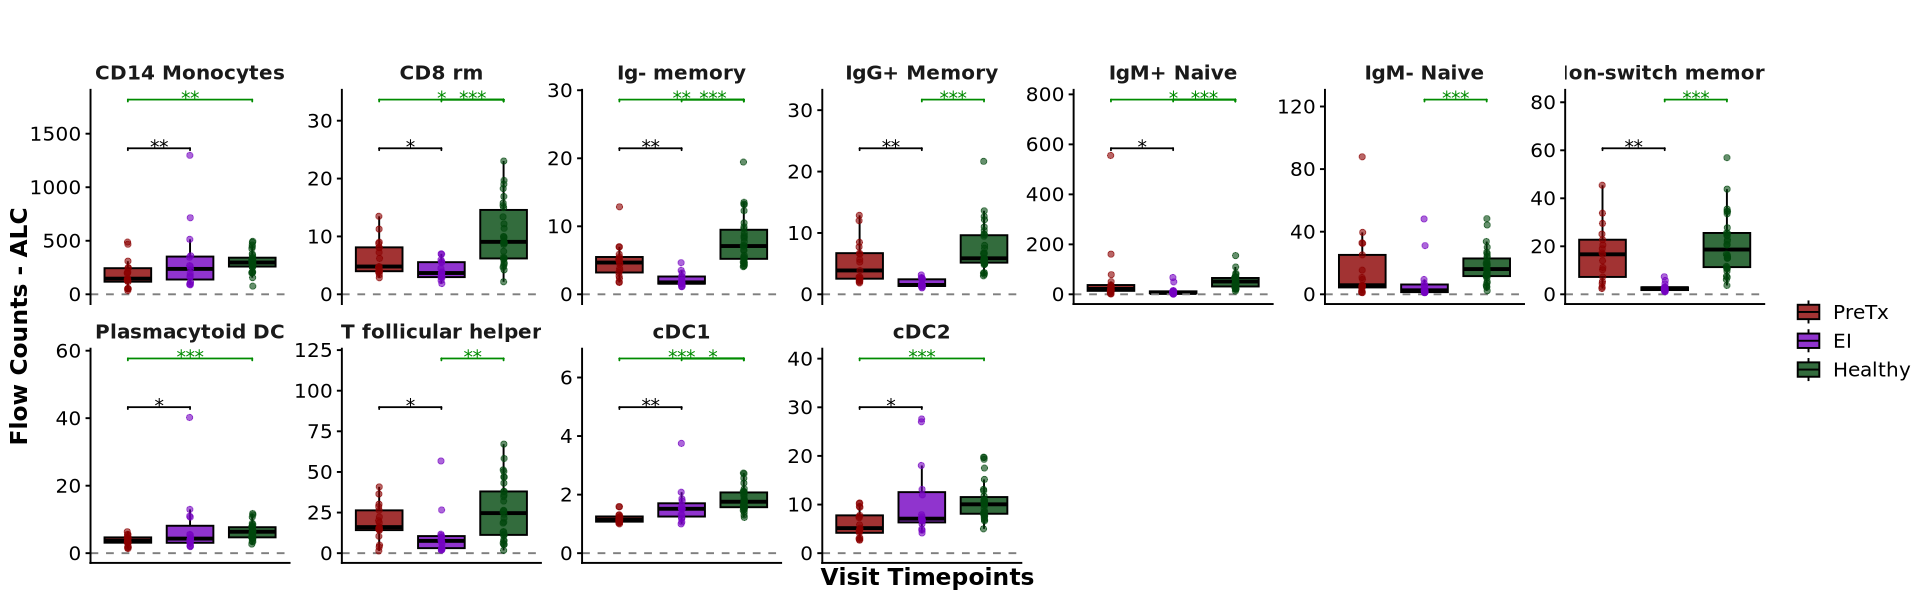

In [8]:
options(repr.plot.width = 16, repr.plot.height = 5)

cellsToPlot <- c(
  "CD14 Monocytes", "CD8 rm", "Ig- memory", "IgG+ Memory", "Plasmacytoid DC", "T follicular helper",
  "Translational B cells", "cDC1", "IgM+ Naive", "IgM- Naive", "Non-switch memory", "cDC2"
)
timesToExclude <- c("ASCT60d", "ASCT1y", "ASCT2y", "PI2C")

visits_in_data <- c("PreTx", "EI", "Healthy")
tp_colors <- c(
  "PreTx"    = "#8B0000",
  "PI2C"     = "#C20272",
  "EI"       = "#7502C2",
  "ASCT60d"  = "#0021B0",
  "ASCT90d"  = "#2346DE",
  "ASCT1y"   = "#038AFF",
  "ASCT2y"   = "#008080",
  "Healthy"  = "#00470D"
)


p <- ggplot(
  mmFiles[Sub_Cohort != "VRd_Dara" & label.visitDetails %in% visits_in_data & uniquePopulationName %in% cellsToPlot],
  aes(x = label.visitDetails, y = pseudo_alc, fill = label.visitDetails)
) +
  geom_boxplot(alpha = 0.8, outlier.shape = NA, color = "black") +
  geom_hline(yintercept = 0, linetype = "dashed", color = "gray50") +
  geom_jitter(
    aes(color = label.visitDetails),
    width = 0.01, size = 1.5, stroke = 0.4, alpha = 0.6, show.legend = FALSE
  ) +
  facet_wrap(~uniquePopulationName, scales = "free_y", nrow = 2, ncol = 7) +
  scale_fill_manual(values = tp_colors) +
  scale_color_manual(values = tp_colors, guide = "none") +
  theme_classic(base_size = 12) +
  theme(
    plot.title = element_text(hjust = 0.5, face = "bold", size = 18, margin = margin(b = 10)),
    axis.title = element_text(size = 14, face = "bold"),
    axis.text = element_text(size = 12),
    axis.text.x = element_blank(),
    axis.ticks.x = element_blank(),
    legend.position = "right",
    legend.text = element_text(size = 12),
    legend.title = element_text(face = "bold", size = 12),
    strip.text = element_text(size = 12, face = "bold"),
    strip.background = element_rect(colour = NA)
  ) +
  labs(x = "Visit Timepoints", y = "Flow Counts - ALC", fill = "") +
  stat_pvalue_manual(
    healthy_df[p.adj < 0.05 & !group1 %in% timesToExclude & uniquePopulationName %in% cellsToPlot],
    label = "p.adj.signif", y.position = "y.position",
    tip.length = 0.01, size = 4, bracket.size = 0.5, color = "green4"
  ) +
  stat_pvalue_manual(
    paired_df[p.adj < 0.05 & !group1 %in% timesToExclude & !group2 %in% timesToExclude & uniquePopulationName %in% cellsToPlot],
    label = "p.adj.signif", y.position = "y.position",
    tip.length = 0.01, size = 4, bracket.size = 0.5, color = "black"
  ) +
  ggtitle("")

p

In [9]:
ggsave("../../data/figure-outputs/supplementary-2/sup_2b.pdf", plot = p, width = 16, height = 5, dpi = 200, device = cairo_pdf)

Warning message:
“Removed 22 rows containing non-finite outside the scale range (`stat_boxplot()`).”


Warning message:
“Removed 22 rows containing missing values or values outside the scale range (`geom_point()`).”
